In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pu_path = r'C:\Users\APC\2526-LTXLDL-Project-1.5\processed\kpi_PU_2023.csv'
df_zones = pd.read_csv(pu_path)

In [4]:
df_zones

,PU_Zone,total_trips,total_revenue,total_distance_miles,median_duration_minutes,p95_duration_minutes,median_speed_mph,avg_passengers,trips_per_day
0,Allerton/Pelham Gardens,655,23446.48,4733.70,29.716667,84.676667,10.462823,1.079389,1.794521
1,Alphabet City,37203,919436.54,116578.31,13.233333,32.833333,10.365905,1.359380,101.926027
2,Arden Heights,285,25705.82,5290.03,58.483333,98.790000,18.279248,1.000000,0.780822
3,Arrochar/Fort Wadsworth,35,2833.49,389.48,22.716667,64.780000,26.274956,1.828571,0.095890
4,Astoria,15980,385146.20,59227.07,14.250000,44.050833,10.985776,1.230038,43.780822
...,...,...,...,...,...,...,...,...,...
256,Woodlawn/Wakefield,935,39649.42,9029.77,33.800000,87.126667,14.563064,1.066310,2.561644
257,Woodside,5928,204183.07,26154.77,15.433333,49.465833,11.727735,1.311572,16.241096
258,World Trade Center,168404,5503390.49,711290.85,18.283333,43.550000,10.522166,1.548289,461.380822
259,Yorkville East,446549,9944026.15,1086184.16,10.266667,27.116667,10.194625,1.305133,1223.421918


In [5]:
# FEATURE EXTRACTION: Trích xuất những dữ liệu dặc trưng nhất để tiến hành phân cụm
features = ['total_trips', 'p95_duration_minutes', 'trips_per_day']
df_feature = df_zones[features].copy()

In [6]:
# DÙNG STANDEARD SCALER: Để đưa có đặc trưng về cùng range phục vụ cho phân cụm
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_feature)


In [7]:
# Metrics để đánh giá mô hình
from sklearn.metrics import silhouette_score

k=2, Silhouette Score=0.7625
k=3, Silhouette Score=0.7798
k=4, Silhouette Score=0.7184
k=5, Silhouette Score=0.5283
k=6, Silhouette Score=0.5340
k=7, Silhouette Score=0.5462
k=8, Silhouette Score=0.5466
k=9, Silhouette Score=0.5188
k=10, Silhouette Score=0.5197


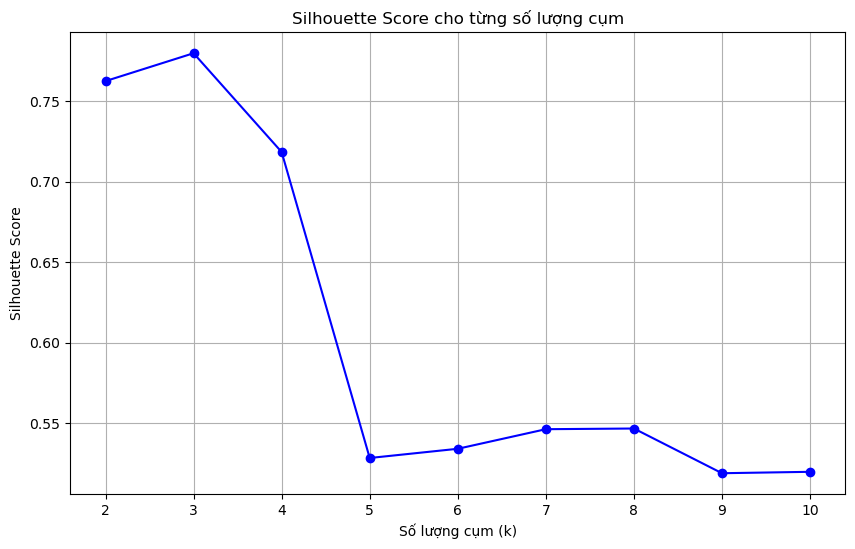

Số cụm có Silhouette Score cao nhất là: 3


In [8]:
k_range = range(2, 11) # Từ 2 đến 10 cụm
silhouette_scores = []
from sklearn.cluster import KMeans
for k in k_range:
    # Chạy K-means với k cụm
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    # Tính score
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

# Vẽ biểu đồ để chọn k tốt nhất
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score cho từng số lượng cụm')
plt.grid(True)
plt.show()

# In ra best k 
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Số cụm có Silhouette Score cao nhất là: {best_k}")


--- ĐẶC ĐIỂM CỦA TỪNG CỤM ---
   Cluster    total_trips  p95_duration_minutes  trips_per_day
0        0   20144.141593             65.944078      55.189429
1        1  807648.187500             32.894271    2212.734760
2        2      15.333333            310.730833       0.042009


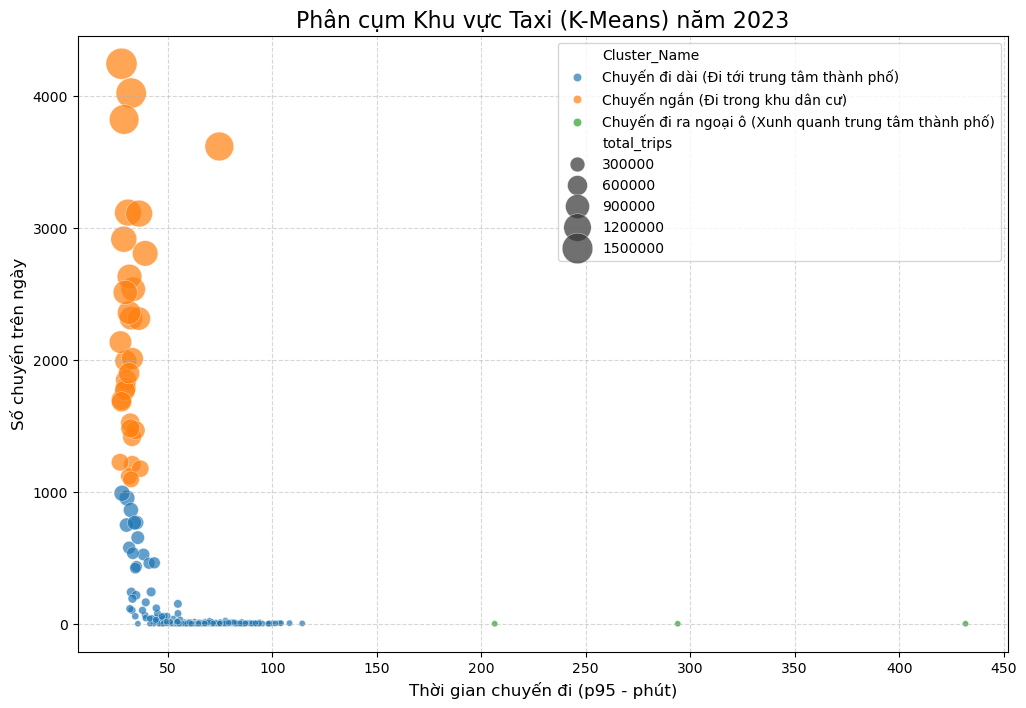

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_zones['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df_zones.groupby('Cluster')[features].mean().reset_index()
print("\n--- ĐẶC ĐIỂM CỦA TỪNG CỤM ---")
print(cluster_summary)

#Giả định cho từng cụm sau khi đã xem summary
cluster_map = {
    0: 'Chuyến đi dài (Đi tới trung tâm thành phố)',      
    1: 'Chuyến ngắn (Đi trong khu dân cư)', 
    2: 'Chuyến đi ra ngoại ô (Xunh quanh trung tâm thành phố)',
}

# Áp dụng tên gọi
df_zones['Cluster_Name'] = df_zones['Cluster'].map(cluster_map)


# 6. TRỰC QUAN HÓA
# Định nghĩa từ điển màu
custom_colors = {
    'Chuyến đi ra ngoại ô (Xunh quanh trung tâm thành phố)': '#2ecc71',      
    'Chuyến đi dài (Đi tới trung tâm thành phố)': '#e74c3c', 
    'Chuyến ngắn (Đi trong khu dân cư)': '#3498db'
}

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_zones, x='p95_duration_minutes', y='trips_per_day', 
                hue='Cluster_Name', size='total_trips', sizes=(20, 500), 
                palette='tab10', alpha=0.7)

plt.title(f'Phân cụm Khu vực Taxi (K-Means) năm 2023', fontsize=16)
plt.xlabel('Thời gian chuyến đi (p95 - phút)', fontsize=12)
plt.ylabel('Số chuyến trên ngày', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()